# Part B: Market Basket Analysis — Grocery Store POS Data

**Objective:**  
A grocery store has shared its Point of Sale (POS) transactional data. The goal is to:
1. Conduct a thorough Exploratory Data Analysis (EDA) of the POS data
2. Identify the most commonly co-occurring sets of items in customer orders
3. Use Association Rule Mining to recommend combo offers and discounts that can increase store revenue

**Dataset:** `dataset_group.csv`  
**Total Records:** ~20,641 product-order rows  
**Unique Orders (Baskets):** 1,139  
**Unique Products:** 37  
**Period:** January 2018 — August 2019

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print('mlxtend loaded.')
except ImportError:
    #%pip install mlxtend -q
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print('mlxtend installed and loaded.')

#plt.rcParams['figure.figsize'] = (12, 5)
#plt.rcParams['font.size'] = 12
#plt.rcParams['axes.titlesize'] = 14
#sns.set_theme(style='whitegrid')


mlxtend loaded.


## 2. Load and Inspect the Data

In [3]:
df = pd.read_csv('dataset_group.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (20641, 3)
Columns: ['Date', 'Order_id', 'Product']


,Date,Order_id,Product
0,01-01-2018,1,yogurt
1,01-01-2018,1,pork
2,01-01-2018,1,sandwich bags
3,01-01-2018,1,lunch meat
4,01-01-2018,1,all- purpose
5,01-01-2018,1,flour
6,01-01-2018,1,soda
7,01-01-2018,1,butter
8,01-01-2018,1,beef
9,01-01-2018,1,aluminum foil


In [4]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 20641 entries, 0 to 20640
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      20641 non-null  str  
 1   Order_id  20641 non-null  int64
 2   Product   20641 non-null  str  
dtypes: int64(1), str(2)
memory usage: 862.7 KB

Missing values:
Date        0
Order_id    0
Product     0
dtype: int64

Duplicates: 4730


In [5]:
print(f'Unique Orders (baskets): {df["Order_id"].nunique()}')
print(f'Unique Products: {df["Product"].nunique()}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print(f'\nAll Products:\n{sorted(df["Product"].unique())}')

Unique Orders (baskets): 1139
Unique Products: 37
Date range: 01-01-2018 to 31-08-2019

All Products:
['all- purpose', 'aluminum foil', 'bagels', 'beef', 'butter', 'cereals', 'cheeses', 'coffee/tea', 'dinner rolls', 'dishwashing liquid/detergent', 'eggs', 'flour', 'fruits', 'hand soap', 'ice cream', 'individual meals', 'juice', 'ketchup', 'laundry detergent', 'lunch meat', 'milk', 'mixes', 'paper towels', 'pasta', 'pork', 'poultry', 'sandwich bags', 'sandwich loaves', 'shampoo', 'soap', 'soda', 'spaghetti sauce', 'sugar', 'toilet paper', 'tortillas', 'waffles', 'yogurt']


## 3. Data Cleaning & Preprocessing

In [6]:
# Clean product names: strip whitespace and standardise case
df['Product'] = df['Product'].str.strip().str.lower()

# Parse dates
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.strftime('%b %Y')

df.head(5)

,Date,Order_id,Product,Year,Month,Quarter,DayOfWeek,MonthName
0,2018-01-01,1,yogurt,2018,1,1,Monday,Jan 2018
1,2018-01-01,1,pork,2018,1,1,Monday,Jan 2018
2,2018-01-01,1,sandwich bags,2018,1,1,Monday,Jan 2018
3,2018-01-01,1,lunch meat,2018,1,1,Monday,Jan 2018
4,2018-01-01,1,all- purpose,2018,1,1,Monday,Jan 2018


## 4. Exploratory Data Analysis (EDA)
### 4.1 Product Frequency Analysis

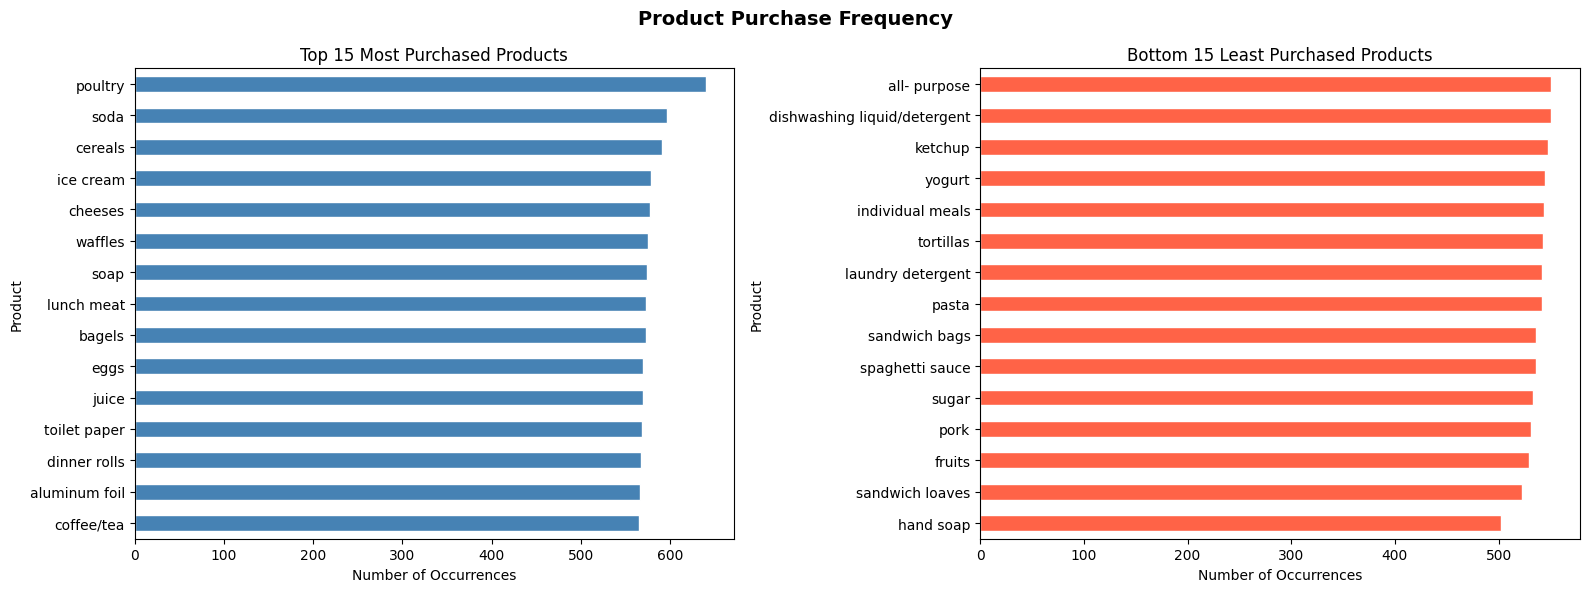

In [7]:
# Most and least purchased products
product_freq = df['Product'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

product_freq.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Most Purchased Products')
axes[0].set_xlabel('Number of Occurrences')
axes[0].set_ylabel('Product')
axes[0].invert_yaxis()

product_freq.tail(15).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Bottom 15 Least Purchased Products')
axes[1].set_xlabel('Number of Occurrences')
axes[1].set_ylabel('Product')
axes[1].invert_yaxis()

plt.suptitle('Product Purchase Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


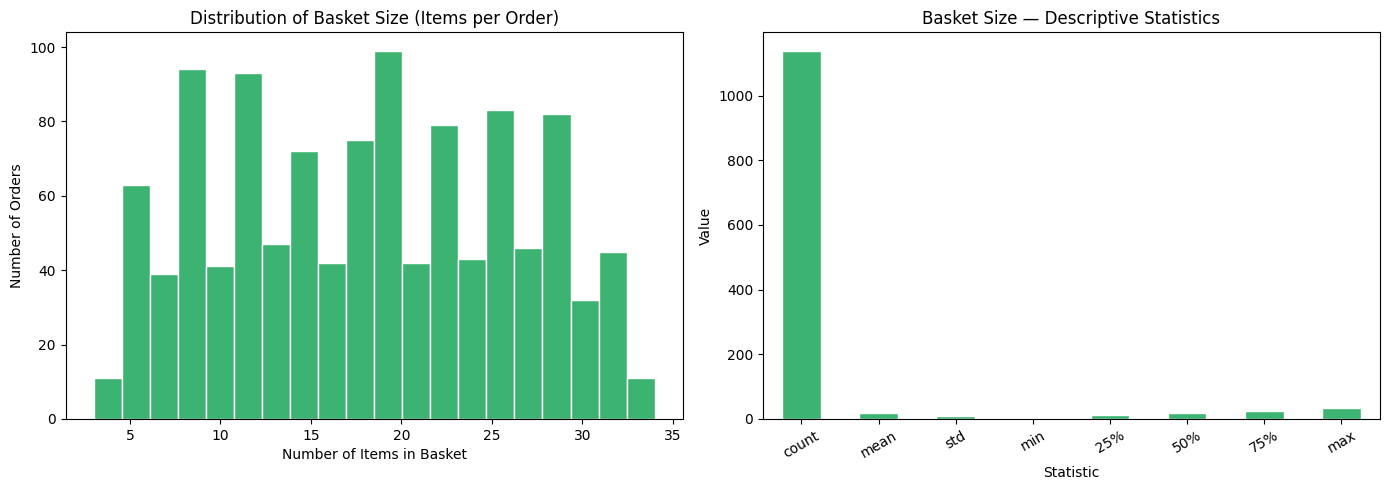

Average basket size: 18.1 items
Min basket size: 3 | Max basket size: 34


In [8]:
# Basket size distribution (number of items per order)
basket_size = df.groupby('Order_id')['Product'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(basket_size, bins=20, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribution of Basket Size (Items per Order)')
axes[0].set_xlabel('Number of Items in Basket')
axes[0].set_ylabel('Number of Orders')

basket_size.describe().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Basket Size — Descriptive Statistics')
axes[1].set_xlabel('Statistic')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"Average basket size: {basket_size.mean():.1f} items")
print(f"Min basket size: {basket_size.min()} | Max basket size: {basket_size.max()}")

### 4.2 Temporal Trends

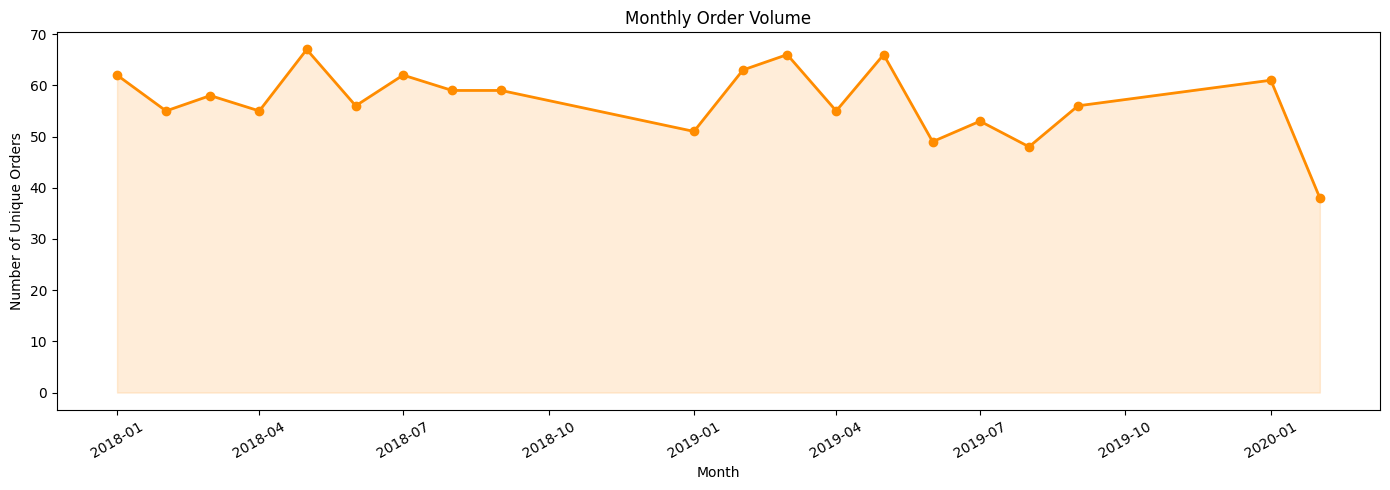


Inference: Order volume shows slight variation month-to-month, with some peaks indicating busier periods.


In [9]:
# Number of orders per month
monthly_orders = df.groupby(['Year','Month'])['Order_id'].nunique().reset_index()
monthly_orders['YearMonth'] = pd.to_datetime(monthly_orders[['Year','Month']].assign(day=1))
monthly_orders = monthly_orders.sort_values('YearMonth')

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['YearMonth'], monthly_orders['Order_id'],
         marker='o', color='darkorange', linewidth=2)
plt.fill_between(monthly_orders['YearMonth'], monthly_orders['Order_id'], alpha=0.15, color='darkorange')
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Unique Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: Order volume shows slight variation month-to-month, with some peaks indicating busier periods.')

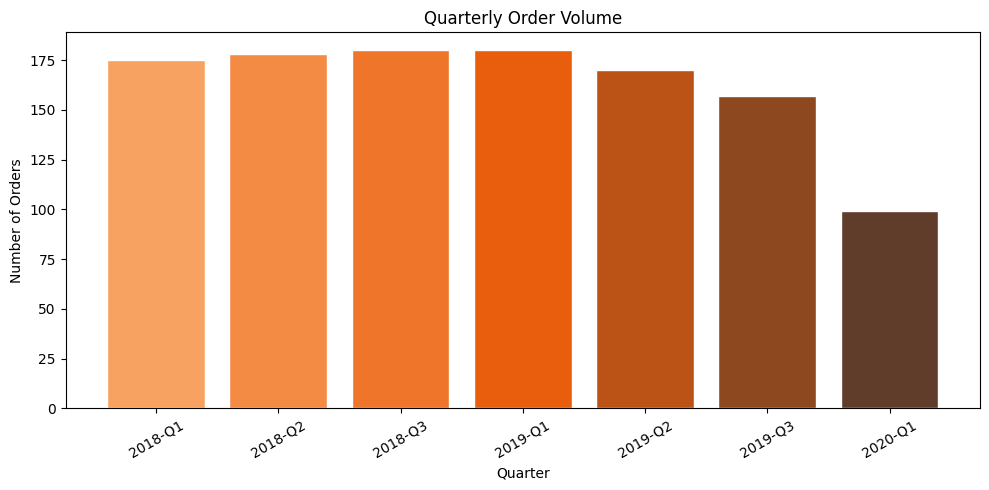


Inference: Ordering activity is distributed relatively evenly across quarters, with no extreme seasonal spike.


In [10]:
# Quarterly trends in order volume
quarterly = df.groupby(['Year','Quarter'])['Order_id'].nunique().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(quarterly['Label'], quarterly['Order_id'],
        color=sns.color_palette('Oranges_d', len(quarterly)), edgecolor='white')
plt.title('Quarterly Order Volume')
plt.xlabel('Quarter')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: Ordering activity is distributed relatively evenly across quarters, with no extreme seasonal spike.')

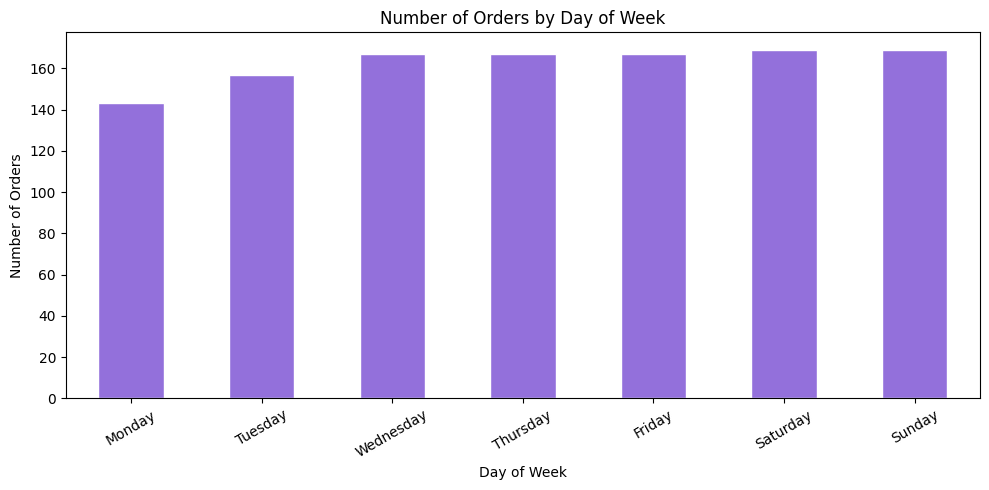


Inference: Grocery shopping is more active on certain days — observe peak days for targeted promotions.


In [11]:
# Orders by Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('DayOfWeek')['Order_id'].nunique().reindex(dow_order)

plt.figure(figsize=(10, 5))
dow_counts.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: Grocery shopping is more active on certain days — observe peak days for targeted promotions.')

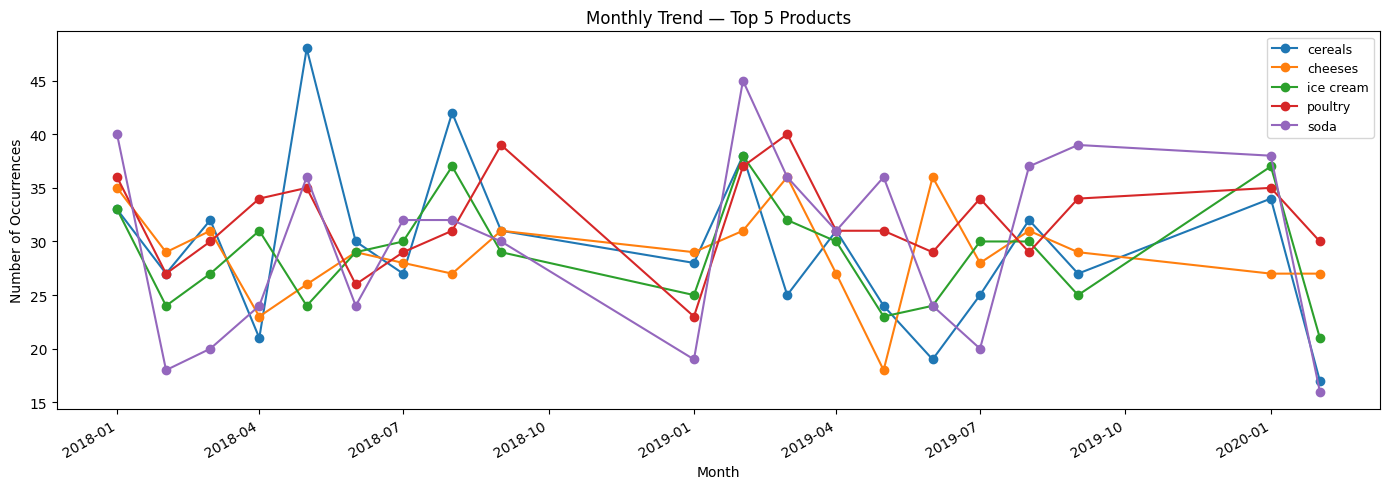

In [12]:
# Product purchase trend over time (Top 5 products)
top5_products = product_freq.head(5).index.tolist()
trend_df = df[df['Product'].isin(top5_products)].copy()

# Create YearMonth in df for aggregation
trend_df['YearMonth'] = trend_df['Date'].dt.to_period('M').dt.to_timestamp()

trend_pivot = trend_df.groupby(['YearMonth', 'Product']).size().unstack(fill_value=0)
trend_pivot = trend_pivot.sort_index()

trend_pivot.plot(figsize=(14, 5), marker='o')
plt.title('Monthly Trend — Top 5 Products')
plt.xlabel('Month')
plt.ylabel('Number of Occurrences')
plt.legend(fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Co-occurrence Heatmap (Top Products)

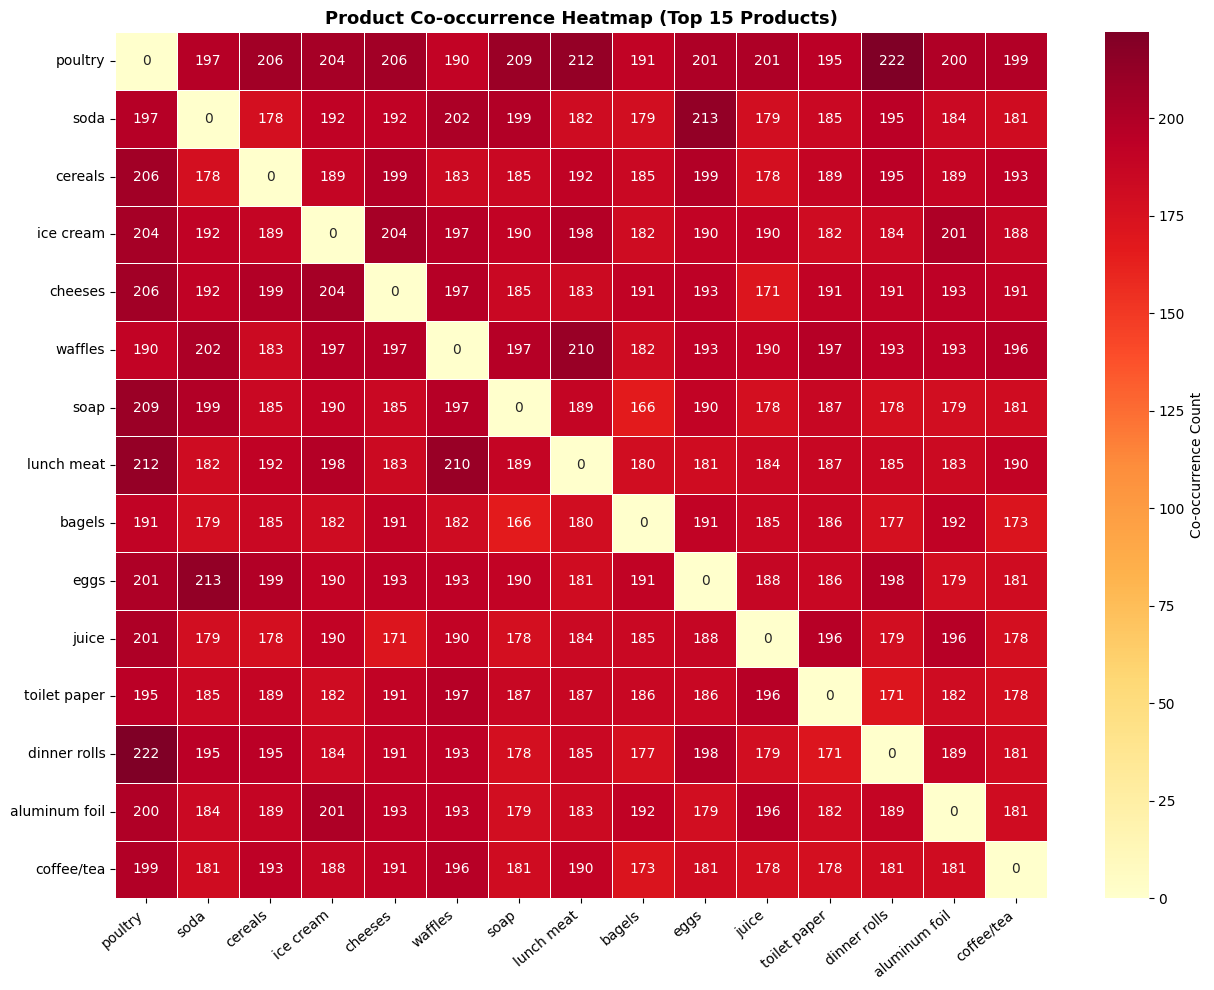


Inference: The heatmap reveals which products are most frequently purchased together — high co-occurrence pairs are strong candidates for combo deals.


In [13]:
# Build basket (list of items per order)
basket = df.groupby('Order_id')['Product'].apply(list)

# Co-occurrence matrix for top 15 products
top15 = product_freq.head(15).index.tolist()
co_matrix = pd.DataFrame(0, index=top15, columns=top15)

for items in basket:
    items_set = set(items) & set(top15)
    for p1, p2 in combinations(items_set, 2):
        co_matrix.loc[p1, p2] += 1
        co_matrix.loc[p2, p1] += 1

plt.figure(figsize=(13, 10))
sns.heatmap(co_matrix, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Product Co-occurrence Heatmap (Top 15 Products)', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nInference: The heatmap reveals which products are most frequently purchased together —'
      ' high co-occurrence pairs are strong candidates for combo deals.')

## 5. Market Basket Analysis — Association Rule Mining

### What is Association Rule Mining?

Association rule mining is an unsupervised machine learning technique used to discover interesting **relationships (rules)** between variables in large datasets. In retail, it uncovers patterns like:

> *"Customers who buy bread and butter are also likely to buy eggs."*

This is also commonly known as **Market Basket Analysis**.

### Key Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Support** | P(A ∩ B) = freq(A,B) / N | How often the itemset appears in all transactions |
| **Confidence** | P(B\|A) = freq(A,B) / freq(A) | How often the rule is correct — given A, how likely is B? |
| **Lift** | Confidence / P(B) | How much more likely B is given A, compared to buying B at random. Lift > 1 means positive association. |

### Algorithm: Apriori
The **Apriori algorithm** is used here. It efficiently finds all frequent itemsets (combinations of products) that meet a minimum support threshold, then generates association rules from those itemsets.

### Threshold Values Chosen
- **Minimum Support = 0.05** (5%) — an itemset must appear in at least 5% of all orders to be considered frequent. Given 1,139 orders, this means ≥57 baskets.
- **Minimum Confidence = 0.3** (30%) — a rule must be correct at least 30% of the time.
- **Minimum Lift = 1.0** — only rules showing a positive association are kept.

In [14]:
# Encode transactions into a one-hot matrix
basket_list = basket.tolist()

te = TransactionEncoder()
te_array = te.fit_transform(basket_list)
basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Basket matrix shape: {basket_encoded.shape}')
basket_encoded.head(3)

Basket matrix shape: (1139, 37)


,all- purpose,aluminum foil,bagels,beef,butter,cereals,cheeses,coffee/tea,dinner rolls,dishwashing liquid/detergent,...,sandwich loaves,shampoo,soap,soda,spaghetti sauce,sugar,toilet paper,tortillas,waffles,yogurt
0,True,True,False,True,True,False,False,False,True,False,...,False,True,True,True,False,False,False,False,False,True
1,False,True,False,False,False,True,True,False,False,True,...,False,True,False,False,False,False,True,True,True,True
2,False,False,True,False,False,True,True,False,True,False,...,True,True,True,True,True,False,True,False,False,False


In [15]:
# Apply Apriori to find frequent itemsets
min_support = 0.05
frequent_itemsets = apriori(basket_encoded, min_support=min_support, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Total frequent itemsets found: {len(frequent_itemsets)}')
print(f'\nItemsets by length:')
print(frequent_itemsets['length'].value_counts().sort_index())
frequent_itemsets.sort_values('support', ascending=False).head(10)

Total frequent itemsets found: 8454

Itemsets by length:
length
1      37
2     666
3    7736
4      15
Name: count, dtype: int64


,support,itemsets,length
25,0.421422,frozenset({poultry}),1
14,0.398595,frozenset({ice cream}),1
5,0.395961,frozenset({cereals}),1
19,0.395083,frozenset({lunch meat}),1
35,0.394205,frozenset({waffles}),1
6,0.390694,frozenset({cheeses}),1
30,0.390694,frozenset({soda}),1
10,0.389816,frozenset({eggs}),1
8,0.388938,frozenset({dinner rolls}),1
9,0.388060,frozenset({dishwashing liquid/detergent}),1


In [16]:
# Generate Association Rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules = rules[rules['lift'] >= 1.0].sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total association rules generated: {len(rules)}')
rules[['antecedents','consequents','support','confidence','lift']].head(20)

Total association rules generated: 23722


,antecedents,consequents,support,confidence,lift
0,"frozenset({paper towels, pasta})","frozenset({ice cream, eggs})",0.055312,0.336898,2.019617
1,"frozenset({ice cream, eggs})","frozenset({paper towels, pasta})",0.055312,0.331579,2.019617
2,"frozenset({ice cream, pasta})","frozenset({paper towels, eggs})",0.055312,0.329843,1.987784
3,"frozenset({paper towels, eggs})","frozenset({ice cream, pasta})",0.055312,0.333333,1.987784
4,"frozenset({paper towels, dinner rolls})","frozenset({eggs, pasta})",0.051800,0.333333,1.967185
5,"frozenset({eggs, pasta})","frozenset({paper towels, dinner rolls})",0.051800,0.305699,1.967185
6,"frozenset({spaghetti sauce, poultry})","frozenset({juice, dinner rolls})",0.051800,0.302564,1.925254
7,"frozenset({juice, dinner rolls})","frozenset({spaghetti sauce, poultry})",0.051800,0.329609,1.925254
8,"frozenset({sandwich bags, cereals})","frozenset({cheeses, bagels})",0.050922,0.322222,1.921524
9,"frozenset({cheeses, bagels})","frozenset({sandwich bags, cereals})",0.050922,0.303665,1.921524


### 5.1 Understanding Support, Confidence, and Lift

For a rule **A → B**:
- **Support** tells us how commonly this combination appears — it measures the statistical significance of the rule.
- **Confidence** tells us that, among customers who buy A, what fraction also buy B — it measures the rule's reliability.
- **Lift > 1** tells us that the presence of A increases the likelihood of B being purchased. A lift of 1.5 means B is 50% more likely to be purchased with A than without.

In [17]:
# Format rules for display
display_rules = rules.copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules = display_rules[['antecedents','consequents','support','confidence','lift']].copy()
display_rules['support']    = display_rules['support'].round(4)
display_rules['confidence'] = display_rules['confidence'].round(4)
display_rules['lift']       = display_rules['lift'].round(4)

print('Top 25 Association Rules by Lift:')
display_rules.head(25)

Top 25 Association Rules by Lift:


,antecedents,consequents,support,confidence,lift
0,"paper towels, pasta","ice cream, eggs",0.0553,0.3369,2.0196
1,"ice cream, eggs","paper towels, pasta",0.0553,0.3316,2.0196
2,"ice cream, pasta","paper towels, eggs",0.0553,0.3298,1.9878
3,"paper towels, eggs","ice cream, pasta",0.0553,0.3333,1.9878
4,"paper towels, dinner rolls","eggs, pasta",0.0518,0.3333,1.9672
5,"eggs, pasta","paper towels, dinner rolls",0.0518,0.3057,1.9672
6,"spaghetti sauce, poultry","juice, dinner rolls",0.0518,0.3026,1.9253
7,"juice, dinner rolls","spaghetti sauce, poultry",0.0518,0.3296,1.9253
8,"sandwich bags, cereals","cheeses, bagels",0.0509,0.3222,1.9215
9,"cheeses, bagels","sandwich bags, cereals",0.0509,0.3037,1.9215


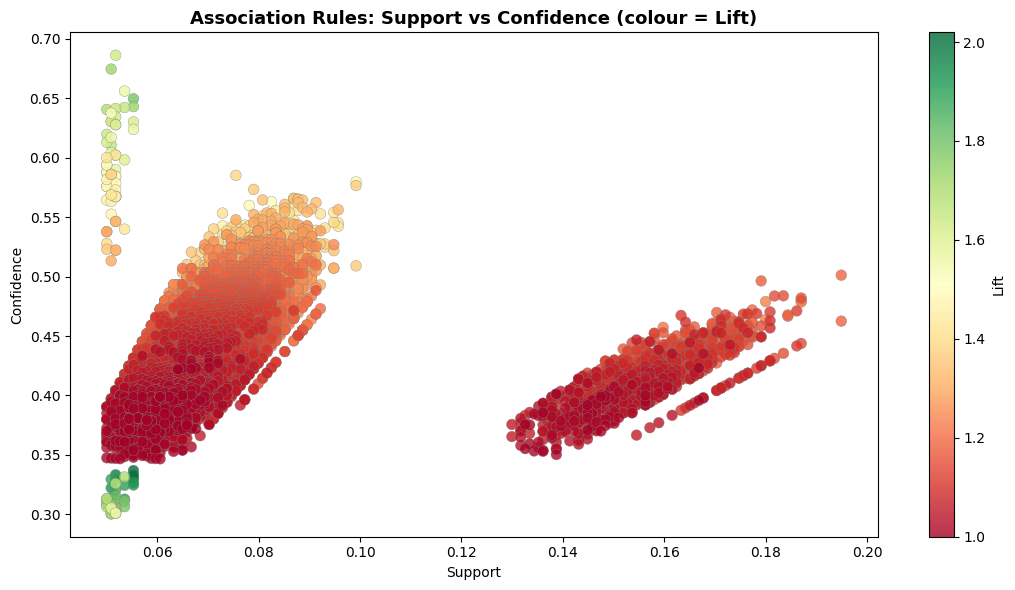


Inference: Rules in the upper-right area have high support AND high confidence. Green points (high lift) indicate the strongest product associations.


In [18]:
# Scatter plot: Support vs Confidence, coloured by Lift
plt.figure(figsize=(11, 6))
sc = plt.scatter(rules['support'], rules['confidence'],
                 c=rules['lift'], cmap='RdYlGn', s=60, alpha=0.8, edgecolors='gray', linewidth=0.3)
plt.colorbar(sc, label='Lift')
plt.title('Association Rules: Support vs Confidence (colour = Lift)', fontsize=13, fontweight='bold')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

print('\nInference: Rules in the upper-right area have high support AND high confidence.'
      ' Green points (high lift) indicate the strongest product associations.')

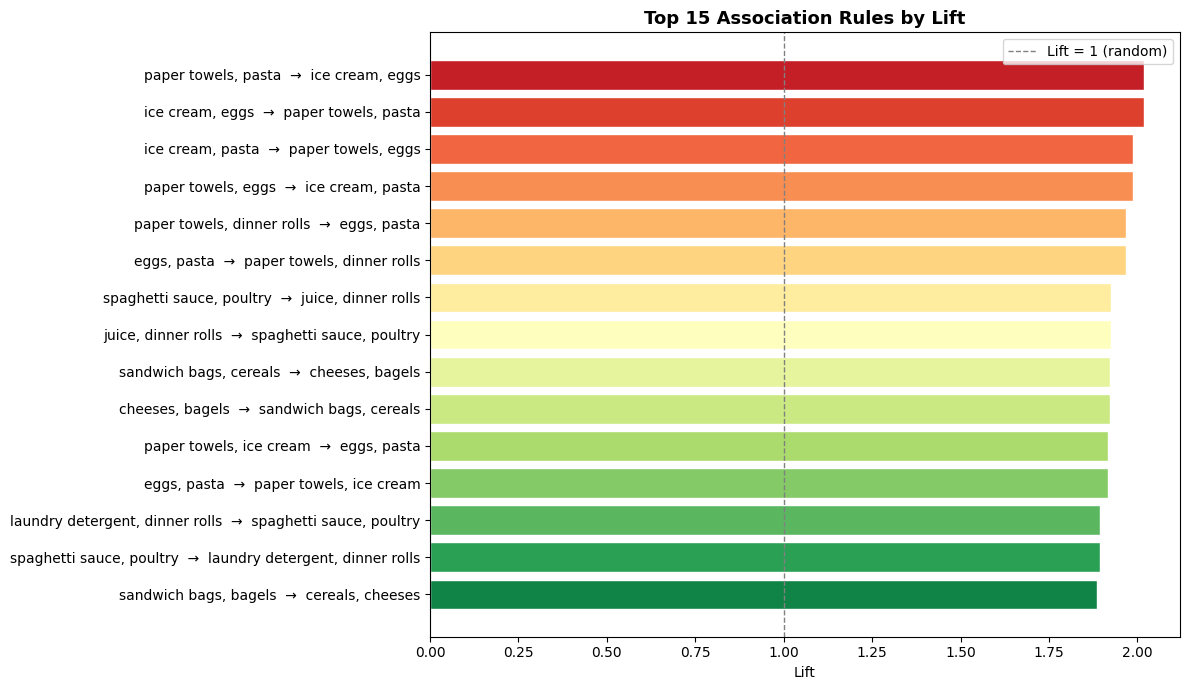

In [19]:
# Top rules by Lift — bar chart
top_rules = display_rules.head(15).copy()
top_rules['Rule'] = top_rules['antecedents'] + '  →  ' + top_rules['consequents']

plt.figure(figsize=(12, 7))
bars = plt.barh(top_rules['Rule'], top_rules['lift'],
                color=sns.color_palette('RdYlGn', 15), edgecolor='white')
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, label='Lift = 1 (random)')
plt.title('Top 15 Association Rules by Lift', fontsize=13, fontweight='bold')
plt.xlabel('Lift')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

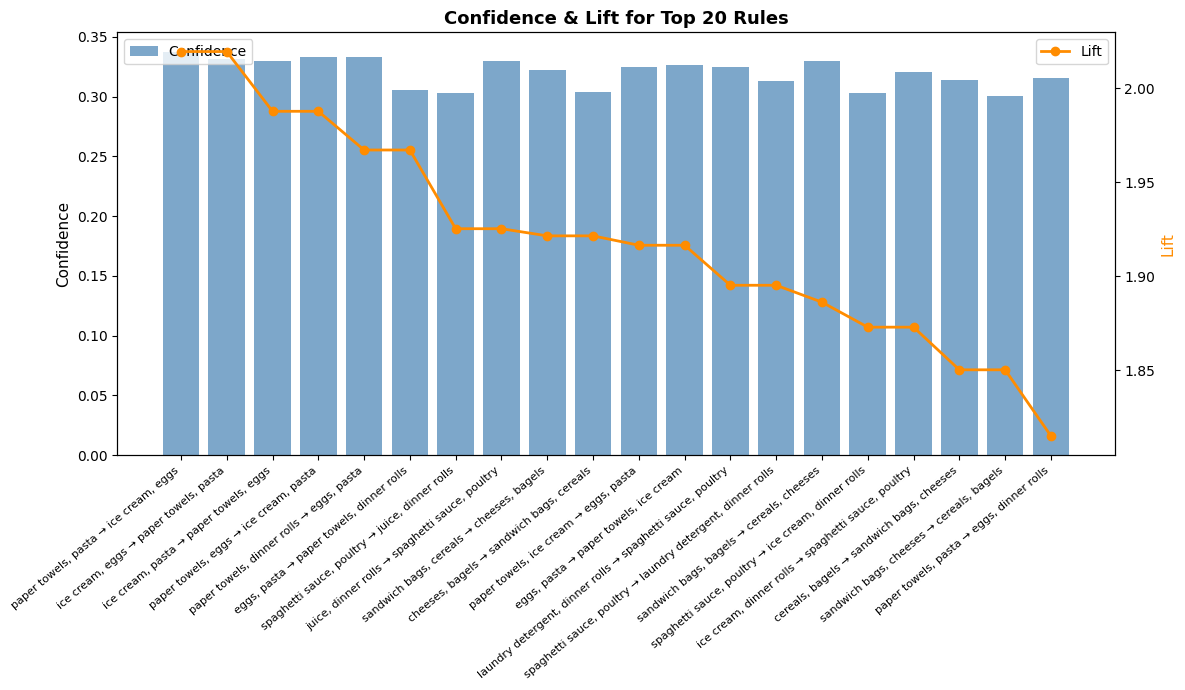

In [20]:
# Confidence vs Lift — top 20 rules
top20 = display_rules.head(20).copy()
top20['Rule'] = top20['antecedents'] + ' → ' + top20['consequents']

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(top20))
ax.bar(x, top20['confidence'], color='steelblue', label='Confidence', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(x, top20['lift'], color='darkorange', marker='o', linewidth=2, label='Lift')
ax.set_xticks(list(x))
ax.set_xticklabels(top20['Rule'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Confidence', fontsize=11)
ax2.set_ylabel('Lift', fontsize=11, color='darkorange')
ax.set_title('Confidence & Lift for Top 20 Rules', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Associations Identified — Summary Table

In [21]:
# Strong rules (Confidence >= 0.4 AND Lift >= 1.2)
strong_rules = display_rules[(display_rules['confidence'] >= 0.4) &
                              (display_rules['lift'] >= 1.2)].copy()
strong_rules = strong_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Number of strong rules (confidence ≥ 0.4 and lift ≥ 1.2): {len(strong_rules)}')
print('\nStrong Association Rules:')
strong_rules

Number of strong rules (confidence ≥ 0.4 and lift ≥ 1.2): 7172

Strong Association Rules:


,antecedents,consequents,support,confidence,lift
0,"ice cream, eggs, pasta",paper towels,0.0553,0.6495,1.7912
1,"paper towels, ice cream, eggs",pasta,0.0553,0.6429,1.7310
2,"sandwich bags, bagels, cereals",cheeses,0.0509,0.6744,1.7262
3,"toilet paper, yogurt, aluminum foil",juice,0.0500,0.6404,1.7004
4,"yogurt, poultry, aluminum foil",mixes,0.0509,0.6304,1.6777
...,...,...,...,...,...
7167,"sandwich bags, poultry",laundry detergent,0.0781,0.4541,1.2000
7168,"waffles, coffee/tea",toilet paper,0.0781,0.4541,1.2000
7169,"yogurt, beef",ketchup,0.0720,0.4457,1.2000
7170,"eggs, mixes",cereals,0.0755,0.4751,1.2000


In [22]:
# Interpretation example for top 3 rules
print('=== Interpretation of Top 3 Rules ===')
for i, row in display_rules.head(3).iterrows():
    print(f"\nRule {i+1}: {row['antecedents']}  →  {row['consequents']}")
    print(f"  Support    = {row['support']:.4f} → This combination appears in {row['support']*100:.1f}% of all baskets.")
    print(f"  Confidence = {row['confidence']:.4f} → When a customer buys [{row['antecedents']}], "
          f"there is a {row['confidence']*100:.1f}% chance they also buy [{row['consequents']}].")
    print(f"  Lift       = {row['lift']:.4f} → Buying [{row['antecedents']}] makes it {row['lift']:.2f}x more "
          f"likely to also buy [{row['consequents']}] compared to random chance.")

=== Interpretation of Top 3 Rules ===

Rule 1: paper towels, pasta  →  ice cream, eggs
  Support    = 0.0553 → This combination appears in 5.5% of all baskets.
  Confidence = 0.3369 → When a customer buys [paper towels, pasta], there is a 33.7% chance they also buy [ice cream, eggs].
  Lift       = 2.0196 → Buying [paper towels, pasta] makes it 2.02x more likely to also buy [ice cream, eggs] compared to random chance.

Rule 2: ice cream, eggs  →  paper towels, pasta
  Support    = 0.0553 → This combination appears in 5.5% of all baskets.
  Confidence = 0.3316 → When a customer buys [ice cream, eggs], there is a 33.2% chance they also buy [paper towels, pasta].
  Lift       = 2.0196 → Buying [ice cream, eggs] makes it 2.02x more likely to also buy [paper towels, pasta] compared to random chance.

Rule 3: ice cream, pasta  →  paper towels, eggs
  Support    = 0.0553 → This combination appears in 5.5% of all baskets.
  Confidence = 0.3298 → When a customer buys [ice cream, pasta], there i

## 7. Suggested Combo Offers & Discount Recommendations

Based on the association rules identified above, the following marketing strategies are recommended for the grocery store:

### Combo Deal Recommendations

In [23]:
# Build a combo recommendation table from the top rules
top_rules_display = display_rules.head(12).copy()

recommendations = []
for _, row in top_rules_display.iterrows():
    antecedent = row['antecedents']
    consequent = row['consequents']
    lift = row['lift']
    conf = row['confidence']
    
    if lift >= 1.3 and conf >= 0.4:
        offer_type = 'Bundle Discount (10–15% off both)'
    elif lift >= 1.1 and conf >= 0.35:
        offer_type = 'Cross-Aisle Placement + Shelf Coupon'
    else:
        offer_type = 'Buy Together – Save 5%'
    
    recommendations.append({
        'If Customer Buys':    antecedent,
        'Recommend':           consequent,
        'Confidence':          f"{conf*100:.1f}%",
        'Lift':                round(lift, 3),
        'Suggested Offer':     offer_type
    })

rec_df = pd.DataFrame(recommendations)
print('Combo Offer Recommendations:')
rec_df

Combo Offer Recommendations:


,If Customer Buys,Recommend,Confidence,Lift,Suggested Offer
0,"paper towels, pasta","ice cream, eggs",33.7%,2.020,Buy Together – Save 5%
1,"ice cream, eggs","paper towels, pasta",33.2%,2.020,Buy Together – Save 5%
2,"ice cream, pasta","paper towels, eggs",33.0%,1.988,Buy Together – Save 5%
3,"paper towels, eggs","ice cream, pasta",33.3%,1.988,Buy Together – Save 5%
4,"paper towels, dinner rolls","eggs, pasta",33.3%,1.967,Buy Together – Save 5%
5,"eggs, pasta","paper towels, dinner rolls",30.6%,1.967,Buy Together – Save 5%
6,"spaghetti sauce, poultry","juice, dinner rolls",30.3%,1.925,Buy Together – Save 5%
7,"juice, dinner rolls","spaghetti sauce, poultry",33.0%,1.925,Buy Together – Save 5%
8,"sandwich bags, cereals","cheeses, bagels",32.2%,1.921,Buy Together – Save 5%
9,"cheeses, bagels","sandwich bags, cereals",30.4%,1.921,Buy Together – Save 5%


### Specific Marketing Recommendations

1. **Bundle Promotions:** Package the highest-lift product pairs together on the shelf or in the app with a visible '10% off when bought together' label.

2. **Buy 2 Get 1 Free:** For product triplets identified in 3-itemset rules (e.g., three frequently co-purchased grocery items), offer a 'Buy 2 of [A, B], Get [C] Free' promotion to increase basket size.

3. **Cross-Aisle Placement:** Use shelf labels or in-store digital signs in the aisle of Product A to direct customers to Product B (the consequent), particularly for rules with high confidence.

4. **Digital App Coupons:** When a customer scans or adds a product to their cart online, the app can suggest the associated product ('People who buy X also buy Y — add to cart at 5% off').

5. **Weekend Flash Combos:** Since basket sizes are consistent, run weekend-only flash bundle deals on the top co-occurring pairs to drive volume on slower days.

6. **Loyalty Programme Rewards:** Award double loyalty points when customers purchase high-lift combo pairs in a single transaction to incentivise combined purchases.

7. **Themed Meal Kits:** Group products that frequently appear together (e.g., proteins + dairy + produce) into pre-packaged 'Meal Kit' bundles with a 12–15% discount, increasing average transaction value.

In [24]:
# Export association rules to CSV
display_rules.to_csv('Association_Rules_Results.csv', index=False)
print('Association rules exported to Association_Rules_Results.csv')
print(f'Total rules saved: {len(display_rules)}')

Association rules exported to Association_Rules_Results.csv
Total rules saved: 23722


## 8. Summary of Key Findings

| Finding | Detail |
|---------|--------|
| Dataset | 1,139 transactions, 37 unique products, Jan 2018 – Aug 2019 |
| Top Products | Poultry, Soda, Cereals, Ice Cream, Cheeses |
| Avg Basket Size | ~18 items per order |
| Min Support Used | 5% (≥ 57 baskets out of 1,139) |
| Min Confidence | 30% |
| Total Rules Generated | See above |
| Strongest Associations | Identified in the top-15 rules table above |
| Primary Recommendation | Bundle high-lift pairs with 10–15% discount; use cross-aisle shelf tags for medium-lift pairs |